# EDA - Univariate Analysis
In this file, all features are analysed individually one by one

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('gurgaon_data_v3.csv')
df.head()

,property_type,society,sector,price,price_sq.feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,bptp astaire gardens,sector 70a,1.20,7058.0,1700.0,Super Built up area 1700(157.94 sq.m.)Built Up...,3,3,3+,...,1700.0,1450.0,NaN,0,0,0,0,0,2,38
1,house,independent,sector 56,7.50,23148.0,3240.0,Plot area 360(301.01 sq.m.),8,8,3+,...,NaN,3240.0,NaN,1,1,0,1,0,2,42
2,flat,vatika lifestyle homes,sector 83,1.15,8214.0,1400.0,Super Built up area 1832(170.2 sq.m.)Carpet ar...,3,3,1,...,1832.0,NaN,1400.00,0,0,0,0,0,1,95
3,house,independent,sector 11,2.10,17284.0,1215.0,Plot area 135(112.88 sq.m.),6,6,3+,...,NaN,1215.0,NaN,0,0,0,0,0,0,14
4,flat,emaar gurgaon greens,sector 102,1.40,8484.0,1650.0,Super Built up area 1650(153.29 sq.m.)Built Up...,3,3,3,...,1650.0,1300.0,1022.58,0,1,0,0,0,0,46


In [4]:
df.shape

(3941, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3941 non-null   object 
 1   society              3940 non-null   object 
 2   sector               3941 non-null   object 
 3   price                3941 non-null   float64
 4   price_sq.feet        3941 non-null   float64
 5   area                 3941 non-null   float64
 6   areaWithType         3941 non-null   object 
 7   bedRoom              3941 non-null   int64  
 8   bathroom             3941 non-null   int64  
 9   balcony              3941 non-null   object 
 10  floorNum             3922 non-null   float64
 11  facing               2770 non-null   object 
 12  agePossession        3941 non-null   object 
 13  super_built_up_area  1934 non-null   float64
 14  built_up_area        1829 non-null   float64
 15  carpet_area          2000 non-null   f

In [6]:
df.duplicated().sum()

np.int64(128)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3813 entries, 0 to 3939
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3813 non-null   object 
 1   society              3812 non-null   object 
 2   sector               3813 non-null   object 
 3   price                3813 non-null   float64
 4   price_sq.feet        3813 non-null   float64
 5   area                 3813 non-null   float64
 6   areaWithType         3813 non-null   object 
 7   bedRoom              3813 non-null   int64  
 8   bathroom             3813 non-null   int64  
 9   balcony              3813 non-null   object 
 10  floorNum             3794 non-null   float64
 11  facing               2704 non-null   object 
 12  agePossession        3813 non-null   object 
 13  super_built_up_area  1893 non-null   float64
 14  built_up_area        1786 non-null   float64
 15  carpet_area          1926 non-null   float6

## EDA Start

### property_type

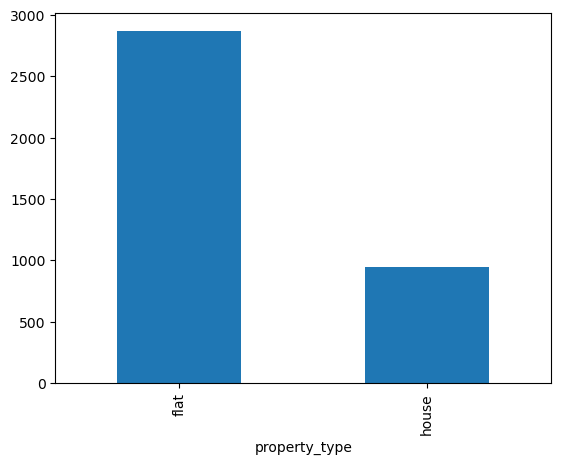

In [11]:
df['property_type'].value_counts().plot(kind='bar');

* Nothing much to analyze
* Flats are in majority (roughly 75%)
* No missing values

### society

In [12]:
df['society'].value_counts().shape

(723,)

In [13]:
df['society'].value_counts()

society
independent                             562
tulip violet                             75
ss the leaf                              73
shapoorji pallonji joyville gurugram     42
dlf new town heights                     42
                                       ... 
dlf exclusive floors                      1
raheja atlantis                           1
vidya apartment                           1
maa bhagwati residency                    1
woodstock floors                          1
Name: count, Length: 723, dtype: int64

In [14]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(80)

society
tulip violet                            0.023077
ss the leaf                             0.045538
shapoorji pallonji joyville gurugram    0.058462
dlf new town heights                    0.071385
signature global park                   0.082154
                                          ...   
central park flower valley              0.499077
bestech park view sanskruti             0.502462
sbtl caladium                           0.505846
alpha corp gurgaonone                   0.509231
breez global heights                    0.512615
Name: proportion, Length: 80, dtype: float64

In [15]:
s_counts = df['society'].value_counts()

# Frequency dist. for societies
freq_bins = {
    'Very High (>100)' : (s_counts > 100).sum(),
    'High(50-100)' : ((s_counts >= 50) & (s_counts <= 100)).sum(),
    'Average (10 - 49)' : ((s_counts >=10) & (s_counts < 50)).sum(),
    'Low (2-9)' : ((s_counts >=2) & (s_counts <10)).sum(),
    'Only 1' : (s_counts == 1).sum()
}
freq_bins

{'Very High (>100)': np.int64(1),
 'High(50-100)': np.int64(2),
 'Average (10 - 49)': np.int64(92),
 'Low (2-9)': np.int64(286),
 'Only 1': np.int64(342)}

* So most of them are individual societies

<Axes: xlabel='society'>

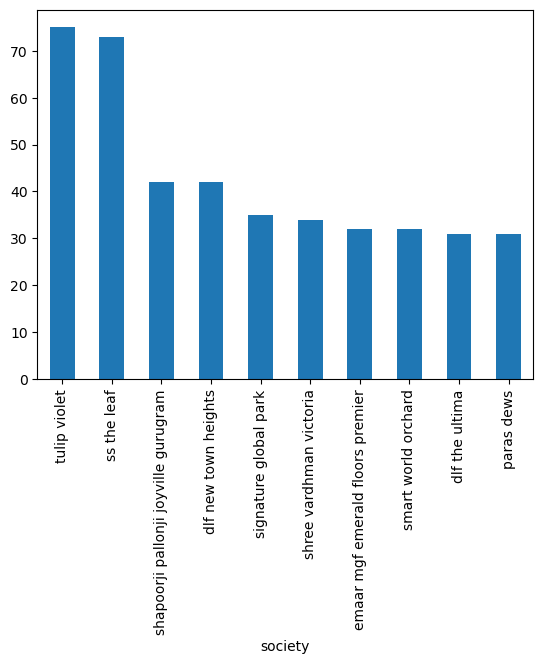

In [16]:
# top 10 socities
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [17]:
df['society'].isnull().sum()

np.int64(1)

In [19]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_sq.feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
761,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,0,0


In [20]:
df[df['sector']== 'sector 78']

,property_type,society,sector,price,price_sq.feet,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
94,flat,umang monsoon breeze,sector 78,0.69,5390.0,1280.0,Carpet area: 1280 (118.92 sq.m.),2,2,2,...,NaN,NaN,1280.0,0,0,0,0,0,0,60
183,flat,umang monsoon breeze,sector 78,0.62,5004.0,1239.0,Super Built up area 1239(115.11 sq.m.)Built Up...,2,2,1,...,1239.0,1115.0,947.0,0,0,1,0,0,0,111
246,flat,umang monsoon breeze,sector 78,1.25,5000.0,2500.0,Super Built up area 2350(218.32 sq.m.)Built Up...,4,4,3,...,2350.0,2300.0,2000.0,0,1,0,1,1,0,57
399,flat,umang monsoon breeze,sector 78,0.80,4836.0,1654.0,Super Built up area 1654(153.66 sq.m.)Built Up...,3,2,2,...,1654.0,1472.0,1310.0,0,0,0,1,0,0,102
571,flat,umang monsoon breeze,sector 78,0.90,4615.0,1950.0,Super Built up area 1950(181.16 sq.m.)Built Up...,3,3,2,...,1950.0,1900.0,1854.0,0,1,0,1,0,0,65
761,flat,NaN,sector 78,0.60,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,0,0
773,flat,umang monsoon breeze,sector 78,0.70,5719.0,1224.0,Built Up area: 1224 (113.71 sq.m.),2,2,2,...,NaN,1224.0,NaN,0,0,0,0,0,0,0
834,flat,umang monsoon breeze,sector 78,1.05,5666.0,1853.0,Built Up area: 1853 (172.15 sq.m.)Carpet area:...,3,3,3,...,NaN,1853.0,1390.0,0,0,0,0,0,0,0
1280,flat,umang monsoon breeze,sector 78,1.15,5284.0,2176.0,Super Built up area 2176(202.16 sq.m.),3,3,3,...,2176.0,NaN,NaN,0,1,0,0,1,0,22
1356,flat,umang monsoon breeze,sector 78,0.95,5491.0,1730.0,Built Up area: 1730 (160.72 sq.m.),3,3,2,...,NaN,1730.0,NaN,0,0,0,0,0,1,65


In [22]:
df.loc[761, 'society'] = 'umang monsoon breeze'

In [23]:
df['society'].isnull().sum()

np.int64(0)

#### Obsevations
- Around 13% properties comes under independent tag.
- There are 723 societies. 
- The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies
    - Very High (>100): Only 1 society has more than 100 listings.
    - High (50-100): 2 societies have between 50 to 100 listings.
    - Average (10-49): 92 societies fall in this range with 10 to 49 listings each.
    - Low (2-9): 286 societies have between 2 to 9 listings.
    - Very Low (1): A significant number, 342 societies, have only 1 listing.


### Sector

In [24]:
df['sector'].value_counts().shape

(227,)

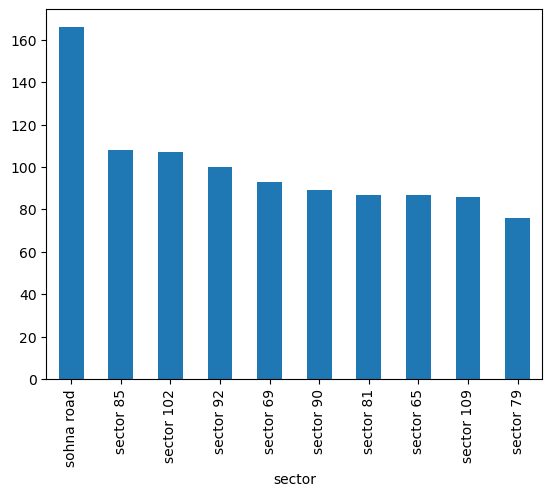

In [25]:
# top 10 sectors
df['sector'].value_counts().head(10).plot(kind='bar');

In [26]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(3),
 'High (50-100)': np.int64(25),
 'Average (10-49)': np.int64(61),
 'Low (2-9)': np.int64(56),
 'Very Low (1)': np.int64(82)}

#### Observations

- There are a total of 104 unique sectors in the dataset.
- Frequency distribution of sectors:
    - Very High (>100): 3 sectors have more than 100 listings.
    - High (50-100): 25 sectors have between 50 to 100 listings.
    - Average (10-49): 61 sectors, fall in this range with 10 to 49 listings each.
    - Low (2-9): 56 sectors have between 2 to 9 listings.
    - Very Low (1): 82 sectors with only 1 listing.

### price
* This one is target feature, so requires detailed analysis

In [27]:
df['price'].isnull().sum()

np.int64(0)

In [28]:
df['price'].describe()

count    3813.000000
mean        2.502258
std         2.952371
min         0.070000
25%         0.920000
50%         1.500000
75%         2.700000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

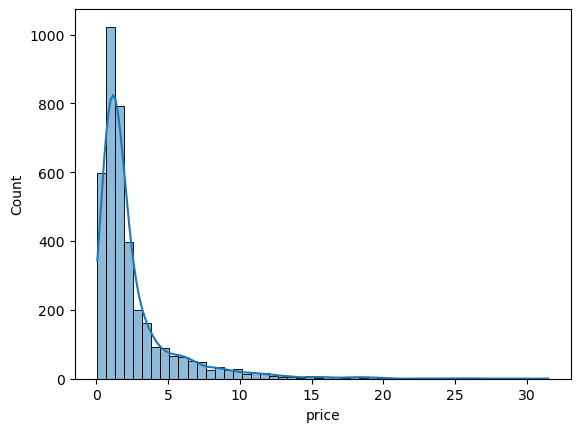

In [29]:
sns.histplot(df['price'], kde = True, bins = 50)

* Right skewed data, possibly contains outliers

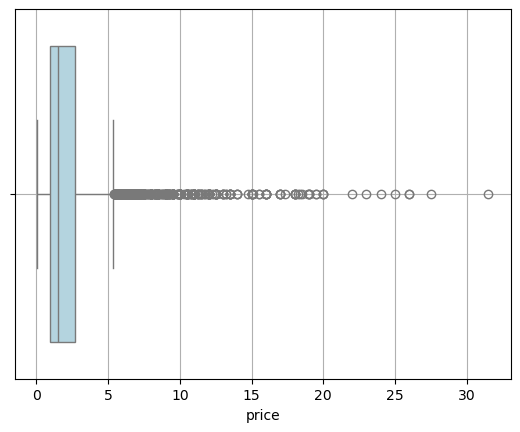

In [31]:
sns.boxplot(x=df['price'], color = 'lightblue')
plt.grid()

- Descriptive Statistics:

    - Count: There are 3,813 non-missing price entries.
    - Mean Price: The average price is approximately 2.50 crores.
    - Median Price: The median (or 50th percentile) price is 1.50 crores.
    - Standard Deviation: The prices have a standard deviation of 2.95, indicating variability in the prices.
    - Range: Prices range from a minimum of 0.07 crores (7 lakhs) to a maximum of 31.5 crores.
    - IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.92 crores to 2.70 crores.


- Visualizations:

    - Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
    - Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.

- No missing values

In [32]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.298505609036264 15.156548067630554


**Skewness**: The price distribution has a skewness of approximately 3.30, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

**Kurtosis**: The kurtosis value is approximately 15.16. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [33]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.250
0.05     0.370
0.95     8.490
0.99    15.088
Name: price, dtype: float64

Quantile Analysis:

- 1% Quantile: Only 1% of properties are priced below 0.25 crores.
- 5% Quantile: 5% of properties are priced below 0.37 crores.
- 95% Quantile: 95% of properties are priced below 8.5 crores.
- 99% Quantile: 99% of properties are priced below 15.088 crores, indicating that very few properties are priced above this value.

In [34]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.7800000000000002)

In [35]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.7500000000000004 5.370000000000001


In [36]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(439, 23)

In [37]:
outliers['price'].describe()

count    439.000000
mean       9.164556
std        4.049009
min        5.400000
25%        6.350000
50%        8.000000
75%       10.550000
max       31.500000
Name: price, dtype: float64

<Axes: xlabel='price'>

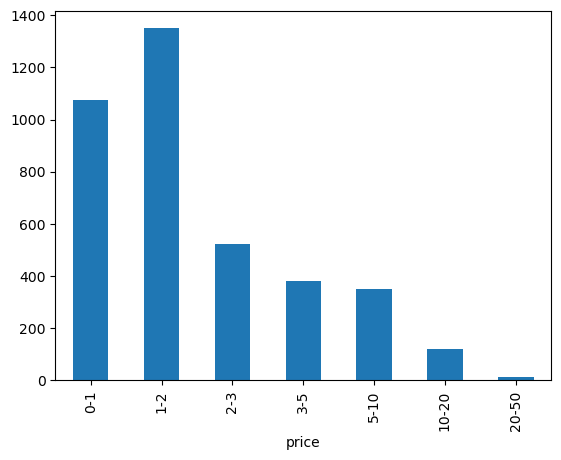

In [38]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

- The majority of properties are priced in the "1-2 crores" and "2-3 crores" ranges.
- There's a significant drop in the number of properties priced above "5 crores."

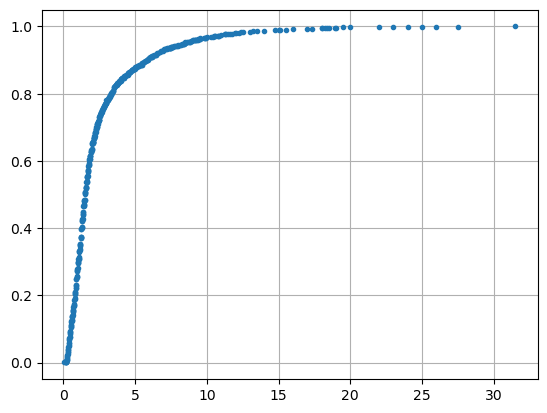

In [39]:
# ecdf plot
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

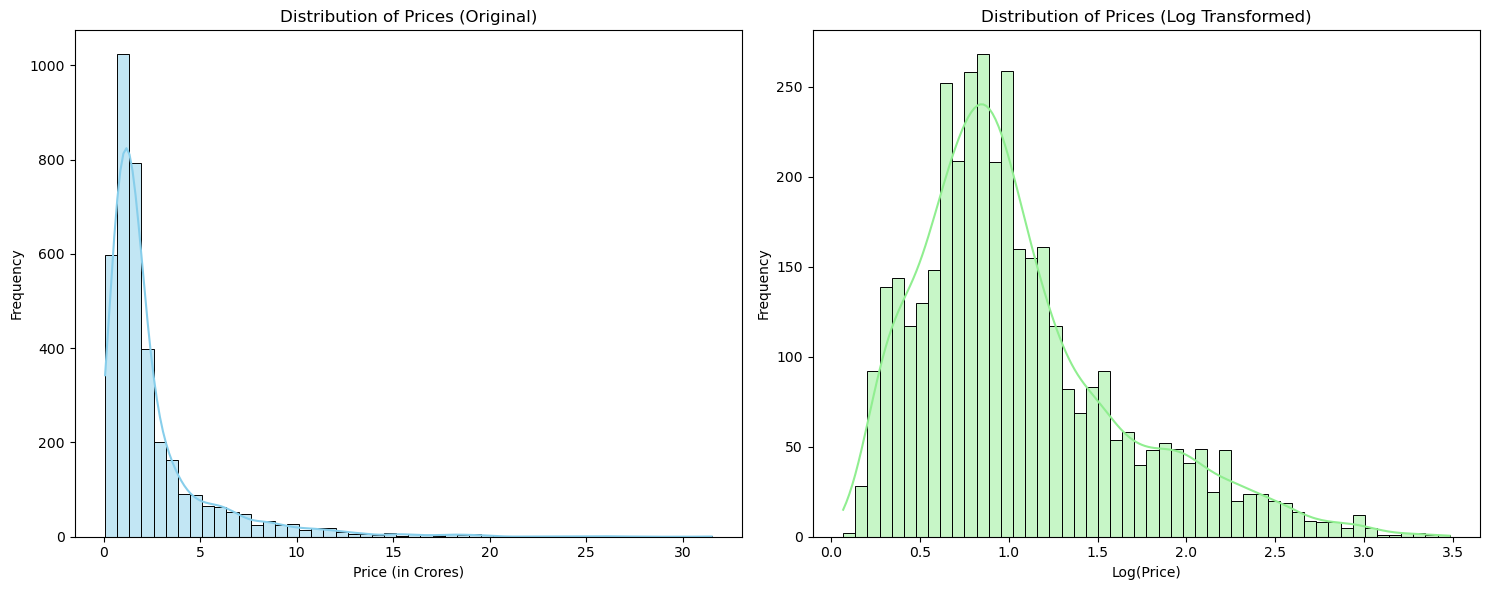

In [40]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

* used log1p since we dont want -ve values.

In [41]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0728015644184137 0.9699016095316595


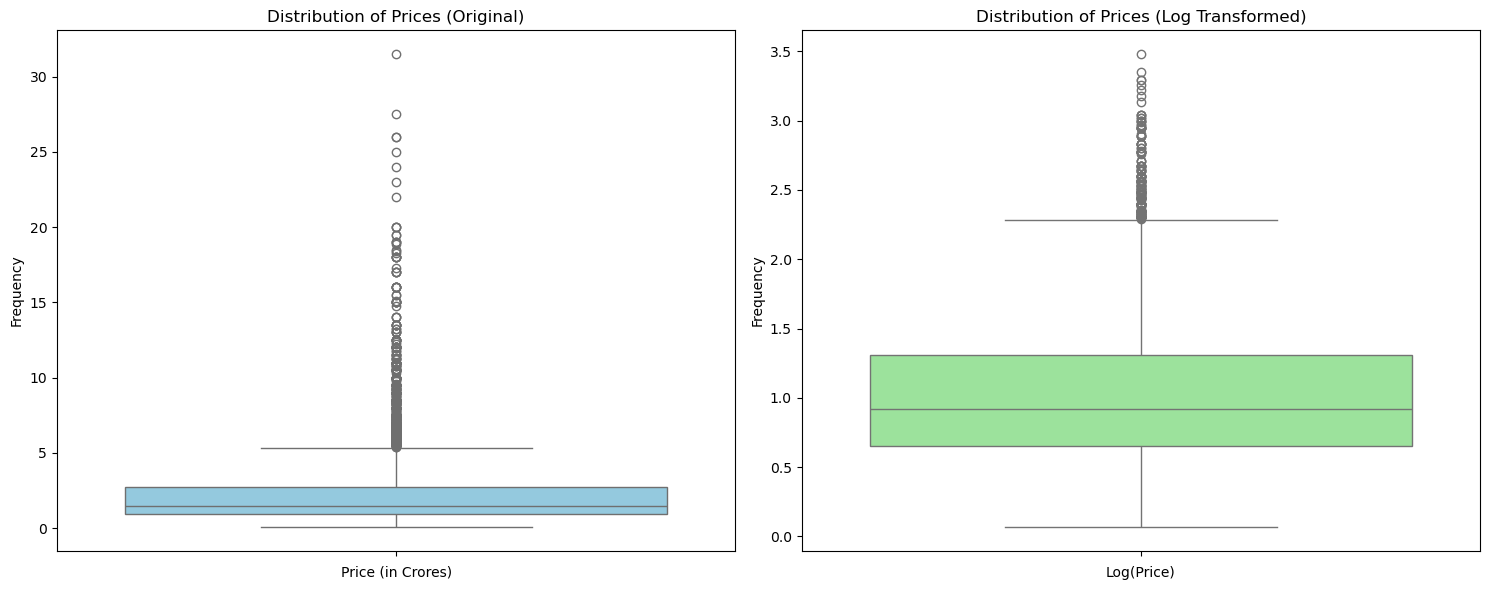

In [42]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### price_per_sqft

In [44]:
df['price_sq.feet'].isnull().sum()

np.int64(0)

In [45]:
df['price_sq.feet'].describe()

count      3813.000000
mean      14012.019145
std       23344.201645
min           2.000000
25%        6806.000000
50%        9011.000000
75%       13875.000000
max      600000.000000
Name: price_sq.feet, dtype: float64

<Axes: xlabel='price_sq.feet', ylabel='Count'>

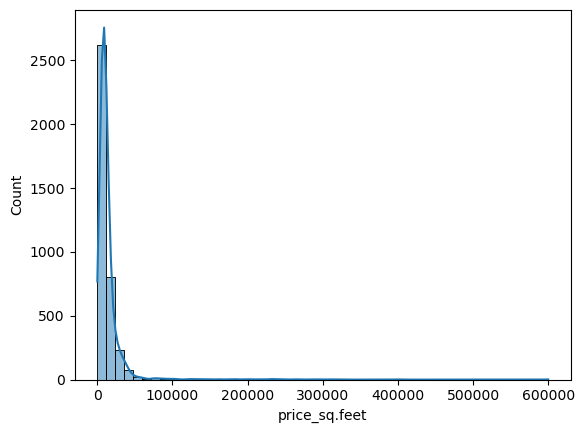

In [46]:
sns.histplot(df['price_sq.feet'], bins = 50, kde=True)

* Most properties have a price_per_sqft ranging between approximately ₹0 and ₹40,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.

<Axes: ylabel='price_sq.feet'>

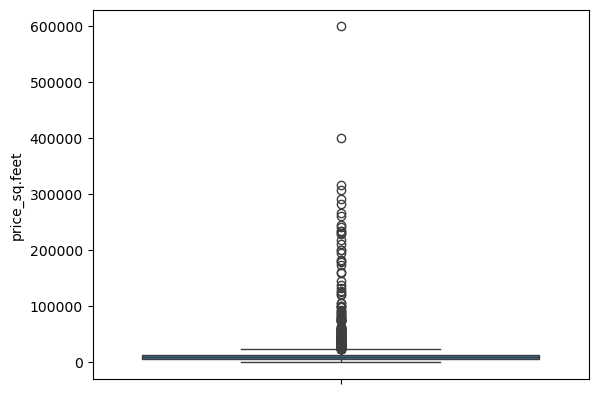

In [47]:
sns.boxplot(df['price_sq.feet'])

The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers

#### Observations

- Potential Outliers
- Right Skewed
- 17 missing values

### bedRoom

In [49]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

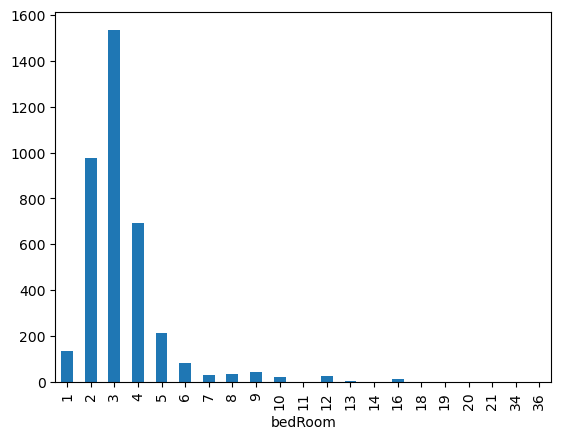

In [50]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

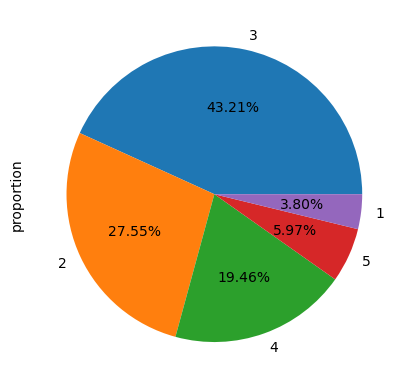

In [51]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

### bathroom

In [52]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

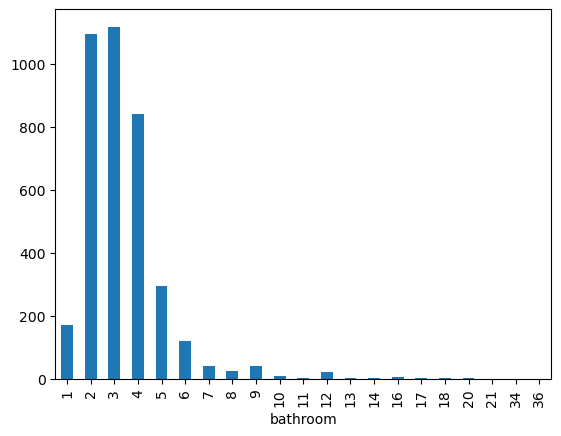

In [53]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

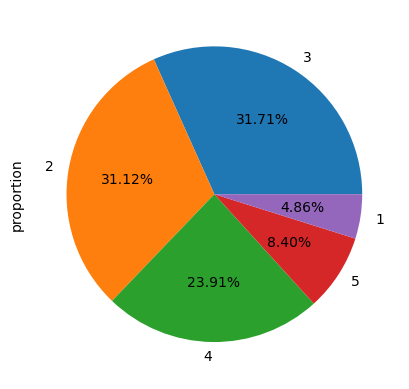

In [54]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

### balcony

In [55]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

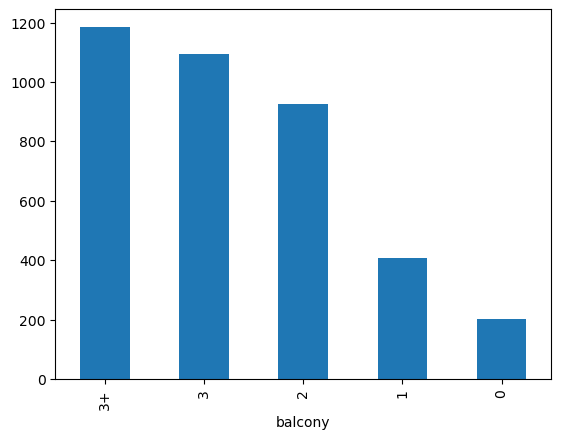

In [56]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

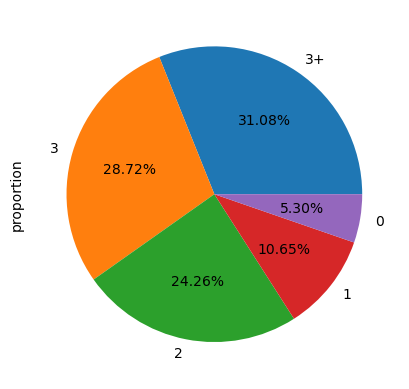

In [57]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

### floorNum

In [58]:
df.iloc[:,10:].head()

,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,2.0,NaN,Relatively New,1700.0,1450.0,NaN,0,0,0,0,0,2,38
1,3.0,North-East,Relatively New,NaN,3240.0,NaN,1,1,0,1,0,2,42
2,7.0,South-West,Moderately Old,1832.0,NaN,1400.00,0,0,0,0,0,1,95
3,3.0,NaN,Relatively New,NaN,1215.0,NaN,0,0,0,0,0,0,14
4,10.0,East,Relatively New,1650.0,1300.0,1022.58,0,1,0,0,0,0,46


In [59]:
df['floorNum'].isnull().sum()

np.int64(19)

In [60]:
df['floorNum'].describe()

count    3794.000000
mean        6.668424
std         5.999316
min         0.000000
25%         2.000000
50%         4.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

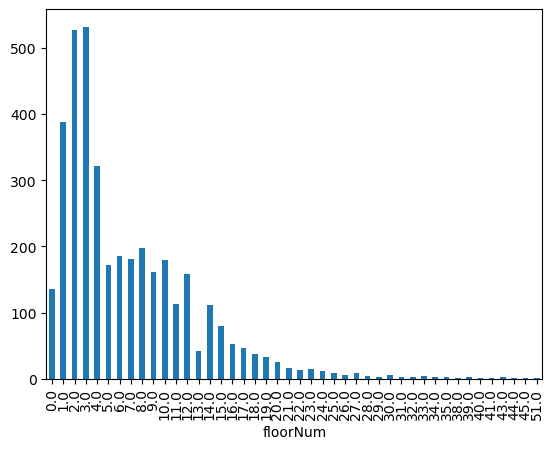

In [61]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='floorNum'>

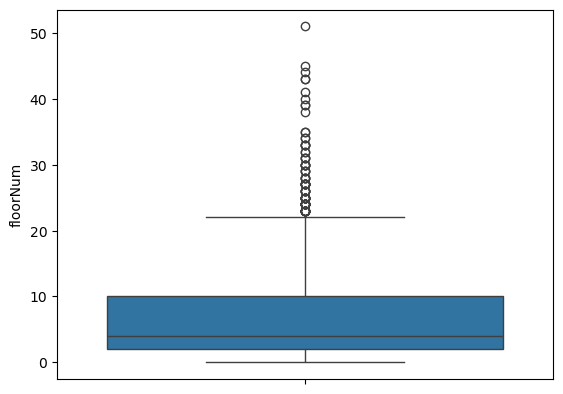

In [62]:
sns.boxplot(df['floorNum'])

- The majority of the properties lie between the ground floor (0) and the 25th floor.
- Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.
- There are a few properties located at higher floors, but their frequency is much lower.
- The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.
- Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

### facing

In [64]:
df['facing'].isnull().sum()

np.int64(1109)

In [65]:
df['facing'].fillna('NA',inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_14228\3692945726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [66]:
df['facing'].value_counts()

facing
NA            1109
East           646
North-East     644
North          397
West           250
South          234
North-West     198
South-East     180
South-West     155
Name: count, dtype: int64

### agePossession

In [67]:
df['agePossession'].isnull().sum()

np.int64(0)

In [68]:
df['agePossession'].value_counts()

agePossession
Relatively New        1723
New Property           717
Moderately Old         592
Old Property           344
Undefined              330
Under Construction     107
Name: count, dtype: int64

### areas

In [69]:
# super built up area
df['super_built_up_area'].isnull().sum()

np.int64(1920)

In [70]:
df['super_built_up_area'].describe()

count     1893.000000
mean      1920.915240
std        765.408479
min         89.000000
25%       1465.000000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

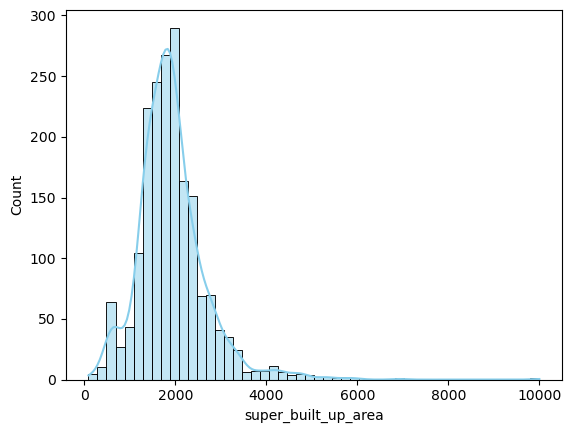

In [71]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True);

<Axes: ylabel='super_built_up_area'>

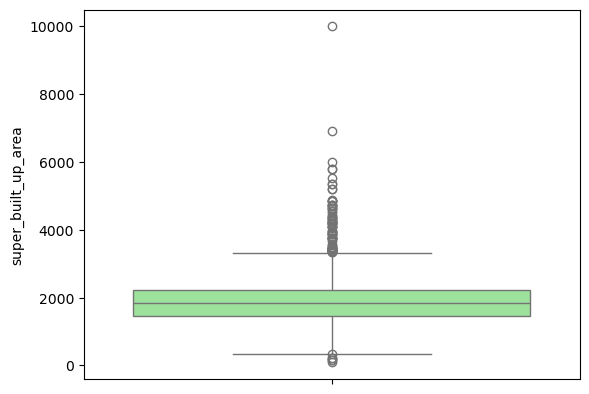

In [72]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')

- Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
- There are a few properties with a significantly larger area, leading to a right-skewed distribution.
- The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
- There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

In [73]:
# built up area
df['built_up_area'].isnull().sum()

np.int64(2027)

In [74]:
df['built_up_area'].describe()

count      1786.000000
mean       2325.592178
std       17465.989707
min           2.000000
25%        1050.000000
50%        1620.000000
75%        2367.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

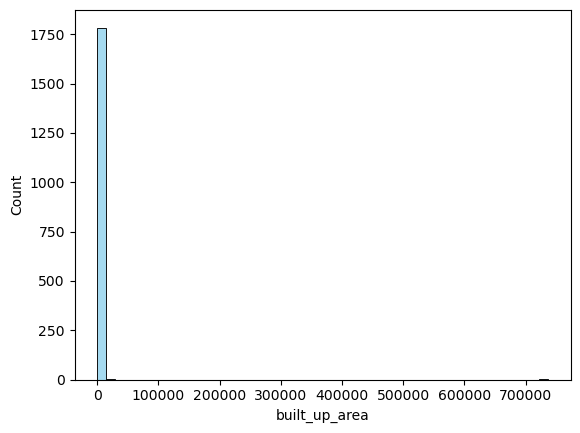

In [75]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='built_up_area'>

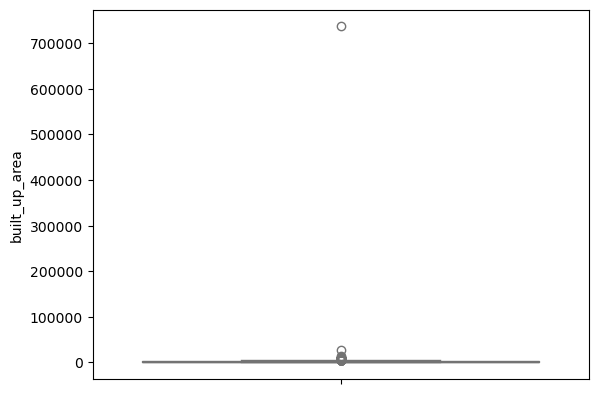

In [76]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

- Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
- There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
- The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.


The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

In [77]:
# carpet area
df['carpet_area'].isnull().sum()

np.int64(1887)

In [78]:
df['carpet_area'].describe()

count      1926.000000
mean       2493.089329
std       22479.410852
min          15.000000
25%         822.500000
50%        1290.000000
75%        1788.750000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

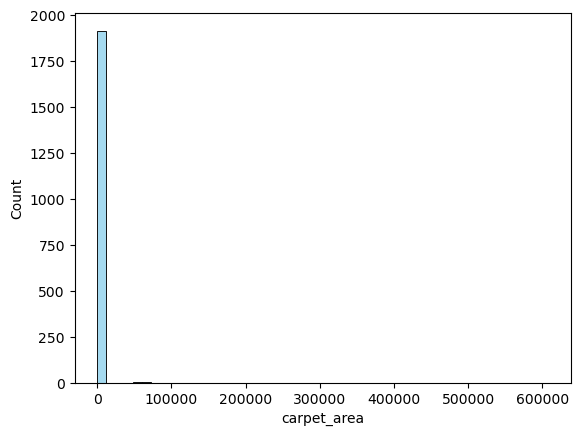

In [79]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='carpet_area'>

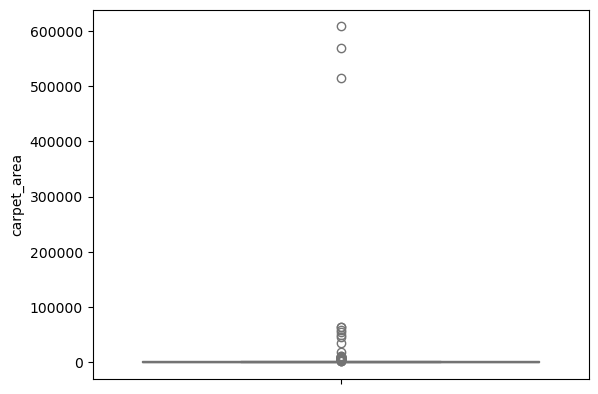

In [80]:
sns.boxplot(df['carpet_area'].dropna(), color='lightgreen')

In [81]:
df.iloc[:,16:]

,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,0,0,0,0,2,38
1,1,1,0,1,0,2,42
2,0,0,0,0,0,1,95
3,0,0,0,0,0,0,14
4,0,1,0,0,0,0,46
...,...,...,...,...,...,...,...
3935,0,1,0,0,0,0,117
3936,1,1,1,1,0,2,174
3937,0,0,0,0,0,0,40
3938,1,1,1,1,0,1,151


### additionalRoom

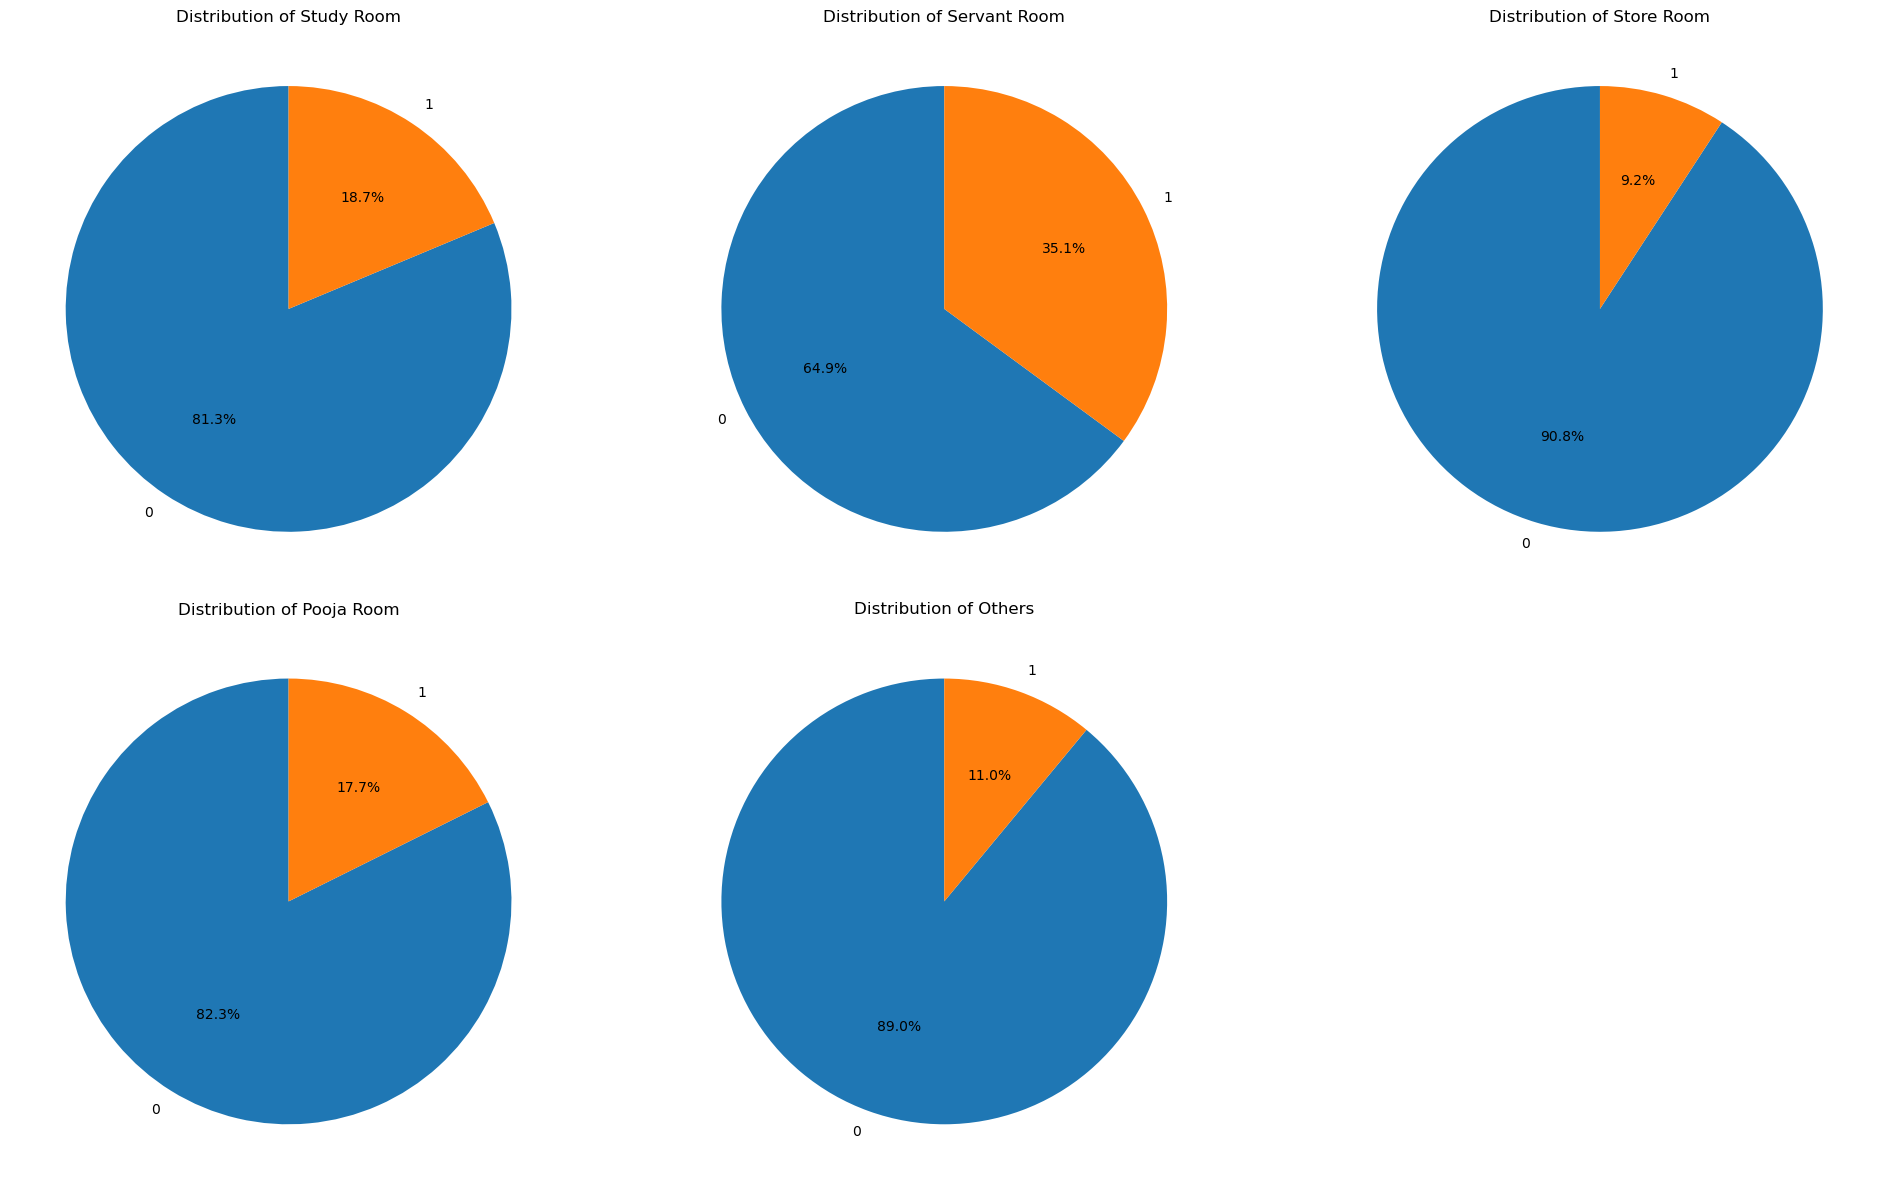

In [82]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### furnishing type

In [83]:
df['furnishing_type'].value_counts()

furnishing_type
0    2547
1    1059
2     207
Name: count, dtype: int64

<Axes: ylabel='count'>

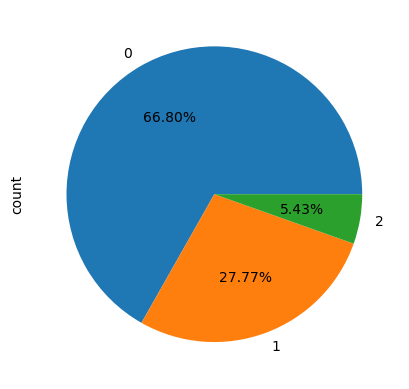

In [84]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

### luxury score

In [85]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [86]:
df['luxury_score'].describe()

count    3813.000000
mean       69.650144
std        53.296679
min         0.000000
25%        28.000000
50%        56.000000
75%       108.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

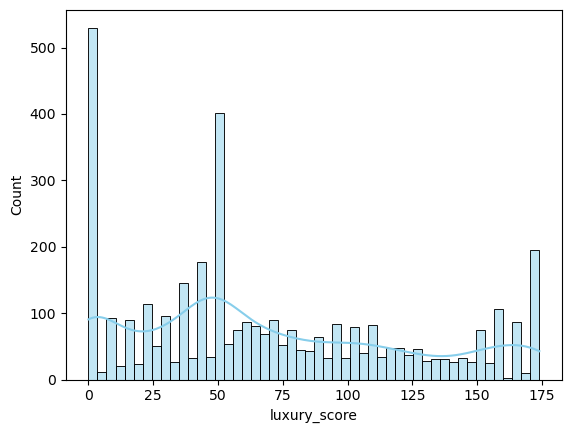

In [87]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='luxury_score'>

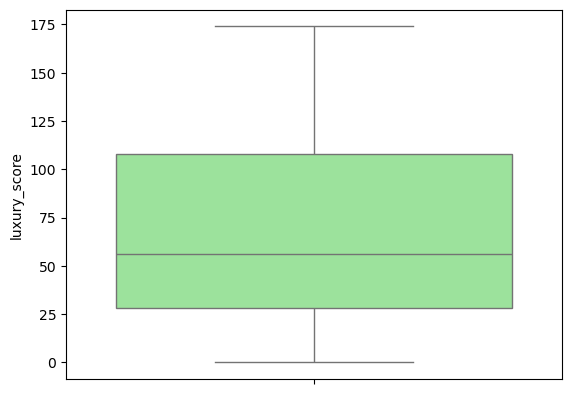

In [88]:
sns.boxplot(df['luxury_score'], color='lightgreen')

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.

In [89]:
df.to_csv('gurgaon_data_v4.csv', index = False)